In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Data & Preprocessing
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, validation_curve

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

# Imbalanced Learn
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

In [ ]:
#wget -O data/raw/telco_churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [41]:
df = pd.read_csv("/Users/arnenyecknyeck/Desktop/keystonedata-platform/keystonedata-platform/notebooks/Telco-Customer-Churn.csv")
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.tail(5)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [44]:
print(f" Shape: {df.shape}")
print(f" Number of features: {df.shape[1]}")
print(f" Column list: {df.columns.tolist}")

 Shape: (7043, 21)
 Number of features: 21
 Column list: <bound method IndexOpsMixin.tolist of Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')>


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [46]:
df['totalcharges'].isna().sum()

0

In [47]:
# Remove ID column
df = df.drop('customerid', axis=1)

# Fix 'totalcharges' by converting to numeric and replacing bad values with 0
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce').fillna(0.0)


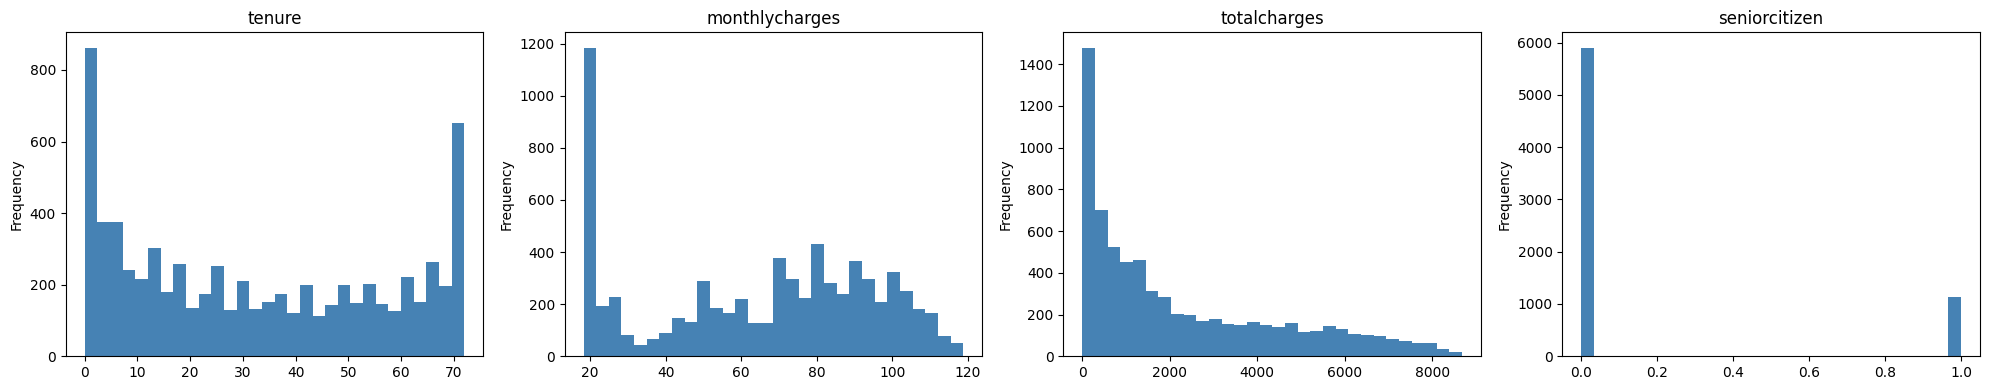

In [48]:
numeric_cols = ['tenure', 'monthlycharges', 'totalcharges', 'seniorcitizen']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue')
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


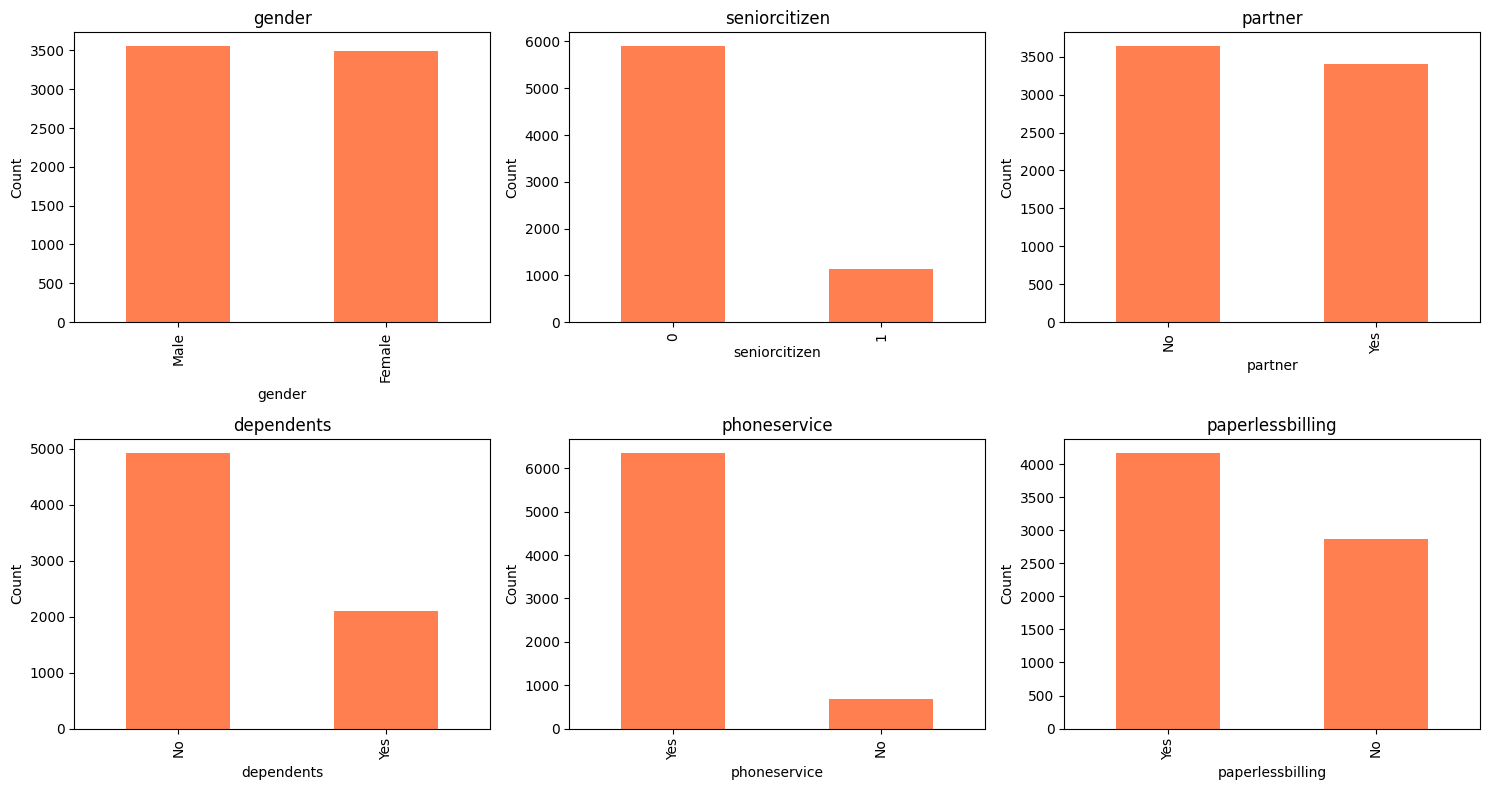

In [49]:
# Categorical columns to visualize
categorical_cols = ['gender', 'seniorcitizen', 'partner', 'dependents',
                    'phoneservice', 'paperlessbilling']

# Create 2x3 grid of bar plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# Plot value counts for each categorical column
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='coral')
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()


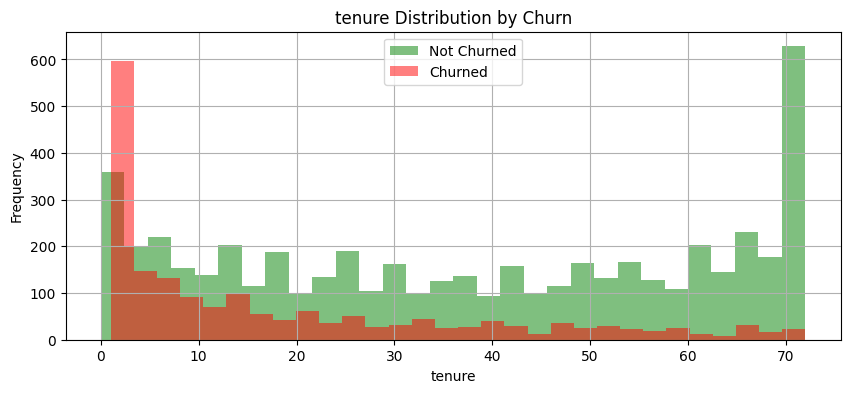

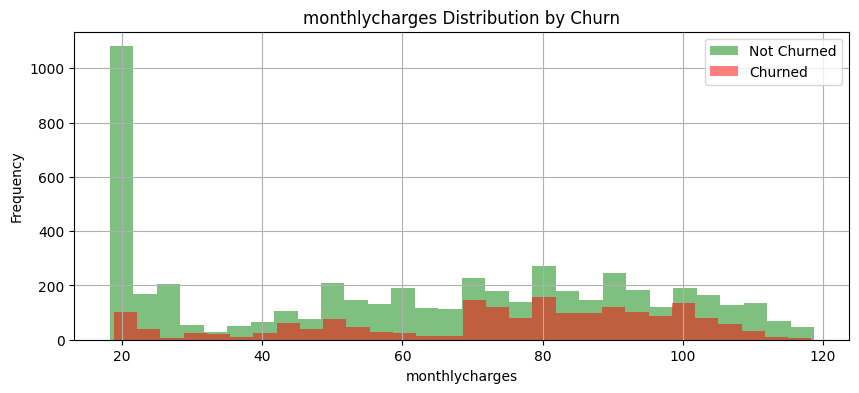

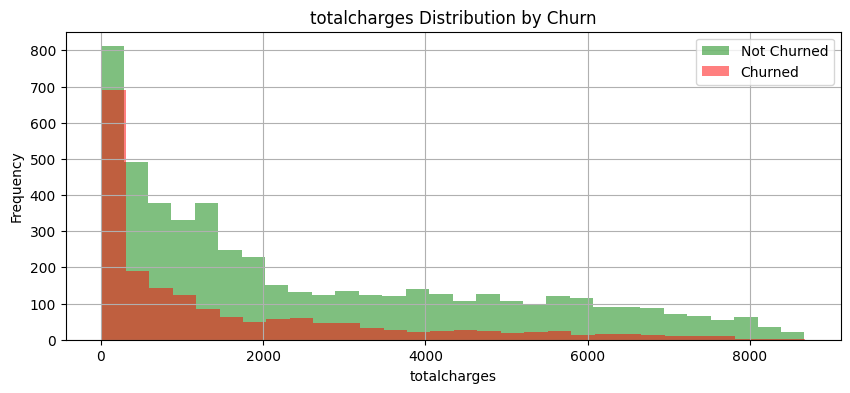

In [50]:
# Distribution of churned vs non-churned customers

for col in ['tenure', 'monthlycharges', 'totalcharges']:
    plt.figure(figsize=(10, 4))
    df[df['churn']=='No'][col].hist(bins=30, alpha=0.5, label='Not Churned', color='green')
    df[df['churn']=='Yes'][col].hist(bins=30, alpha=0.5, label='Churned', color='red')
    plt.title(f'{col} Distribution by Churn')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Tenure Distribution by Churn
# Churn is higly concentrated in month 1 to 5. Customers who survive past 10 months rarely churn.
# Stakeholders should invest in a structured onboarding that can help them assess if a client is most like to past th 90 day mark or not.

# Monthly Charges Distribution by Churn
# The 'non-churned' spikes at the low end, showing that most retained customers are on lower-cost plans. 
# A solution would be to review pricing for mid-tier plans.

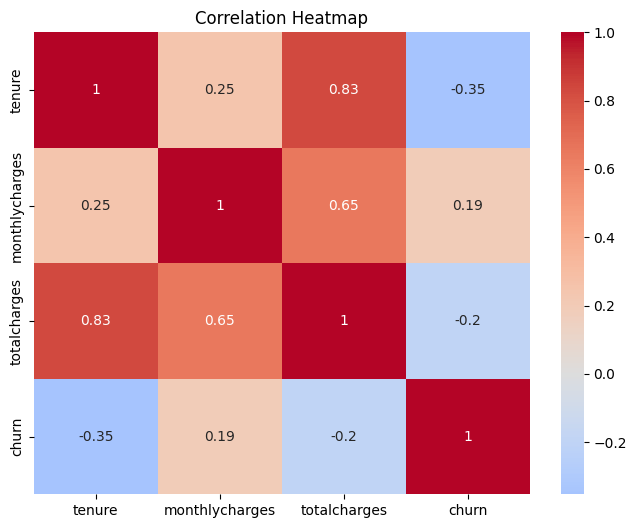

In [51]:
# Fix totalcharges blank spaces — replace with median
df['totalcharges'] = df['totalcharges'].replace(' ', np.nan)
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

# Hot encoding label yes:1 no:0
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

# See relationships between all numerical features
correlation = df[['tenure', 'monthlycharges', 'totalcharges', 'churn']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Churn Rate by Senior Citizen
# Senior citizens churn at 42% vs 24% for non-seniors, well above the 26.5% average.
# Stakeholders could create a senior-specific retention plan with simplified pricing, dedicated support line, or a loyalty discount triggered at 6 months.

# Churn Rate by Partner
# Customers without a partner churn have a higher churn rate of 32% vs 20% for those with partners.
# Target single customers with bundle or family plan incentives to increase stickiness

In [52]:
print(df.columns.tolist())

['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [53]:
# One-hot encode multi-class categorical columns (drop_first avoids dummy trap)
multiclass_cols = ['multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
                   'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
                   'contract', 'paymentmethod']

df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)


In [15]:
# BASELINE MODEL

## train test split
X = df.drop('churn', axis = 1).select_dtypes(include=np.number)
y =df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [54]:

dummy_clf = DummyClassifier(strategy='prior')
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.73450070989115

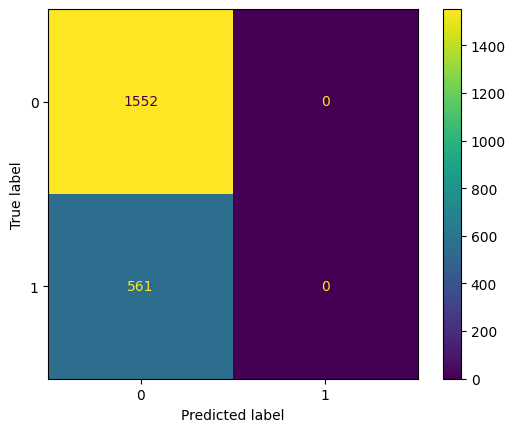

In [55]:
ConfusionMatrixDisplay.from_estimator(dummy_clf, X_test, y_test);

In [58]:
binary_cols = ['gender', 'partner', 'dependents', 'phoneservice', 'paperlessbilling']
mapping = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}
for col in binary_cols:
    df[col] = df[col].replace(mapping)



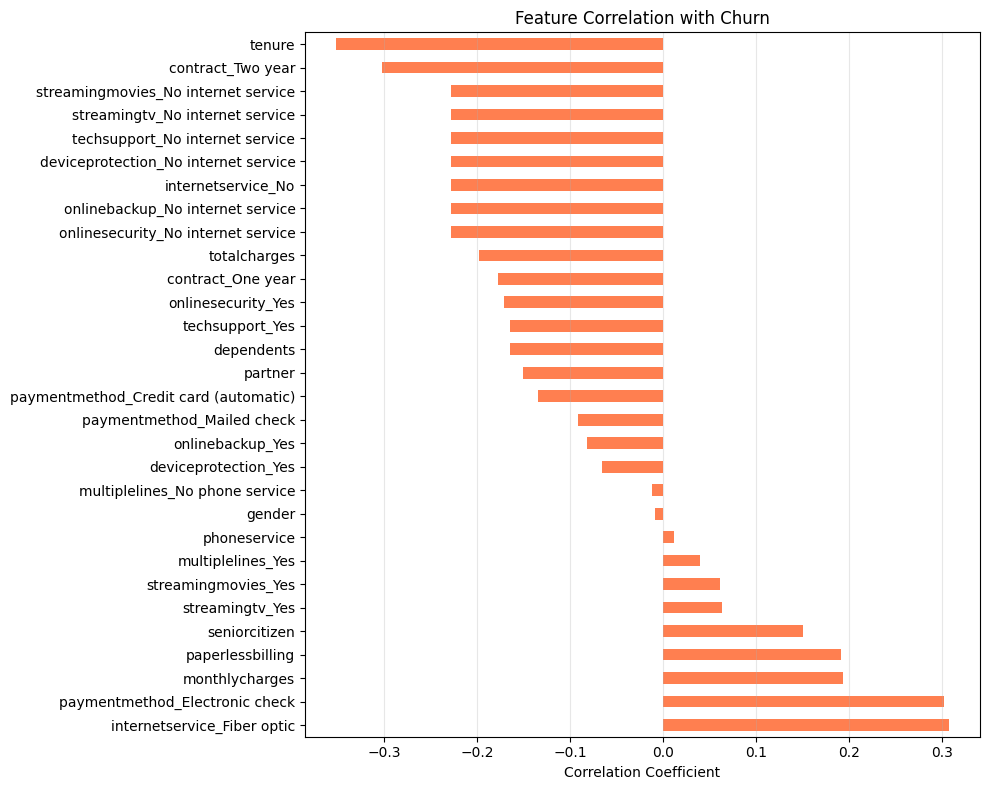

In [59]:
## Feature corr with Churm
churn_corr = df.corr()['churn'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
churn_corr[1:].plot(kind='barh', color='coral')
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

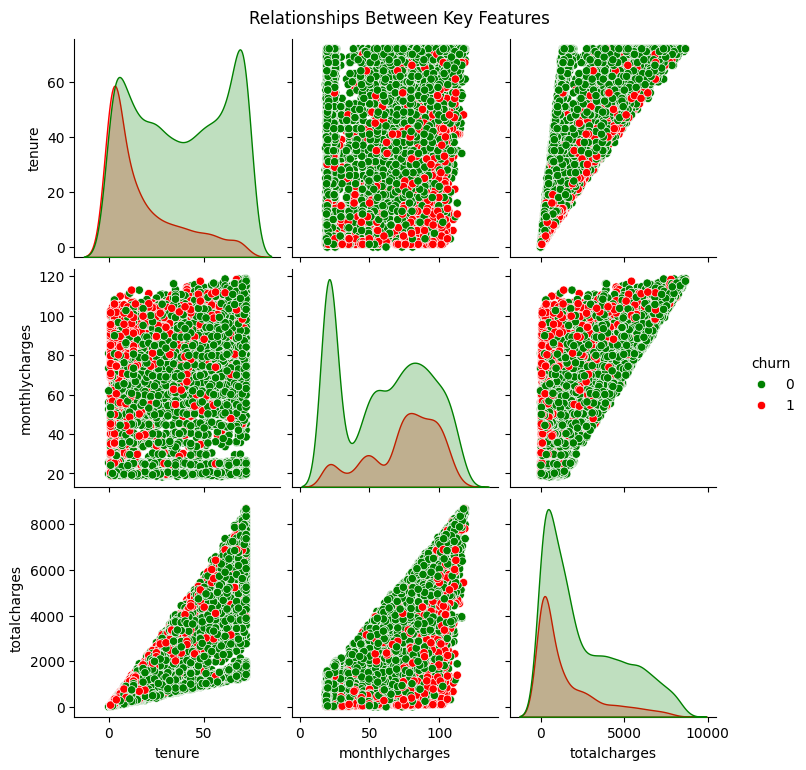

In [60]:
## pairplot key features
key_features = ['tenure', 'monthlycharges', 'totalcharges', 'churn']
sns.pairplot(df[key_features], hue='churn', palette={0: 'green', 1: 'red'})
plt.suptitle('Relationships Between Key Features', y=1.02)
plt.show()

In [62]:
## check for independancy
corr = X.corr(method = 'pearson', numeric_only= True)
corr_pairs = corr.unstack().drop_duplicates().abs().sort_values(ascending = False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(10)

tenure          totalcharges      0.826178
monthlycharges  totalcharges      0.651174
tenure          monthlycharges    0.247900
seniorcitizen   monthlycharges    0.220173
                totalcharges      0.103006
                tenure            0.016567
dtype: float64

In [64]:
## check if dependent variable is binary.
y.value_counts()

#it is binary


churn
0    5174
1    1869
Name: count, dtype: int64

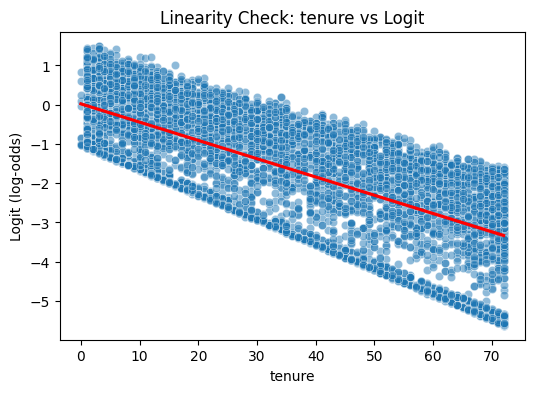

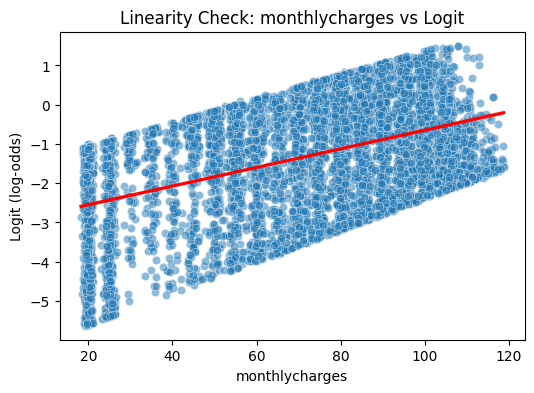

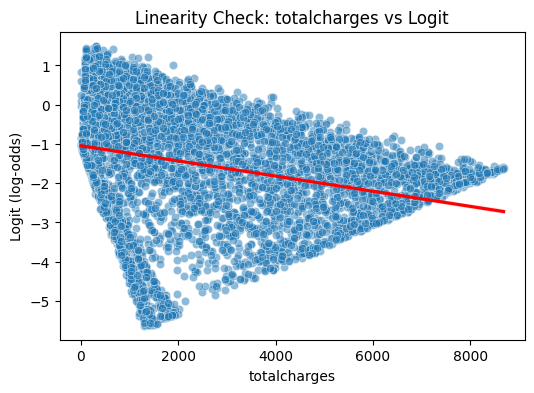

In [65]:
## Check for linearity
# Define continuous numeric predictors (excluding ID and const)
cont_feats = ['tenure', 'monthlycharges', 'totalcharges']

# Create a figure
y = df['churn']

model = LogisticRegression(max_iter=1000)
model.fit(df[cont_feats], y)

df['pred_prob'] = model.predict_proba(df[cont_feats])[:, 1]

df['logit'] = np.log(df['pred_prob'] / (1 - df['pred_prob']))


for feature in cont_feats:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[feature], y=df['logit'], alpha=0.5)
    sns.regplot(x=df[feature], y=df['logit'], scatter=False, color='red')
    plt.title(f'Linearity Check: {feature} vs Logit')
    plt.xlabel(feature)
    plt.ylabel('Logit (log-odds)')
    plt.show()


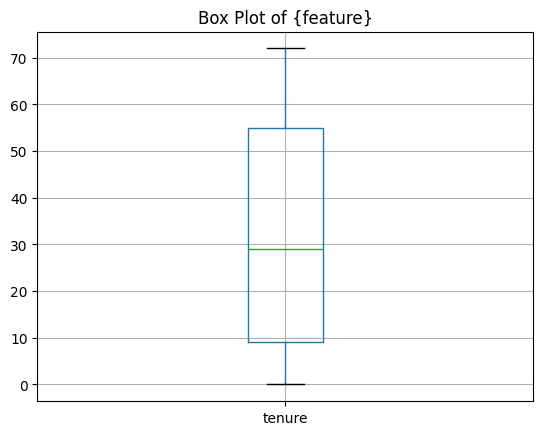

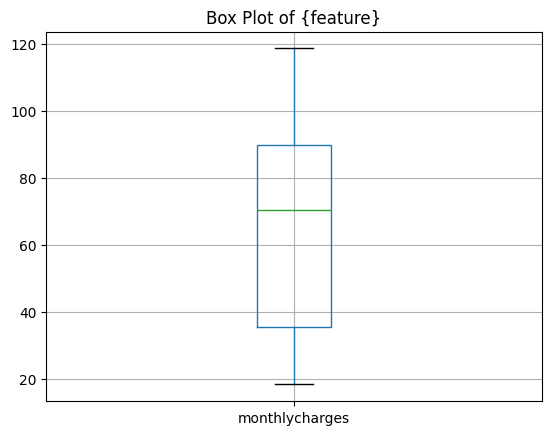

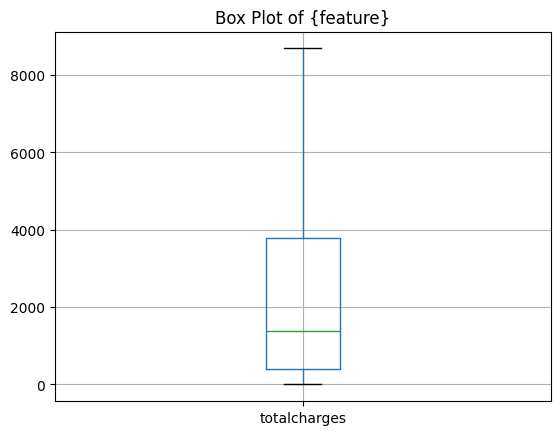

In [66]:
# Checking for outliers.
cont_feats = ['tenure', 'monthlycharges', 'totalcharges']
for feature in cont_feats:
  df.boxplot(column=feature)
  plt.title("Box Plot of {feature}")
  plt.show()

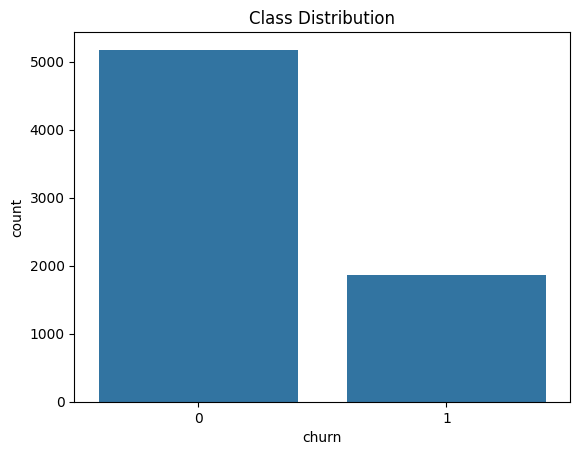

In [67]:
## check for class imbalance
sns.countplot(x=df['churn'])
plt.title("Class Distribution")
plt.show()

In [68]:
## log transformation to continuous features due to non linearity. Log transform (use log1p to handle zeros)
df['log_tenure'] = np.log1p(df['tenure'])
df['log_monthlycharges'] = np.log1p(df['monthlycharges'])
df['log_totalcharges'] = np.log1p(df['totalcharges'])

# Update continuous features list
cont_feats = ['log_tenure', 'log_monthlycharges', 'log_totalcharges']



In [69]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check if any feature is identical to target
for col in X.columns:
    if (X[col] == y).all():
        print(f" {col} is identical to target!")

Duplicate rows: 22


In [70]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (7021, 36)


# ------------------ LOGISTIC REGRESSION MODEL ------------------ #


In [71]:
df.head(10)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,pred_prob,logit,log_tenure,log_monthlycharges,log_totalcharges
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,True,False,0.315333,-0.775301,0.693147,3.429137,3.429137
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,0.131843,-1.884760,3.555348,4.059581,7.544597
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,True,0.474524,-0.101992,1.098612,4.004602,4.692723
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,0.044517,-3.066335,3.828641,3.768153,7.518471
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,True,False,0.602461,0.415728,1.098612,4.272491,5.028148
5,0,0,0,0,8,1,1,99.65,820.50,1,...,False,False,False,True,False,0.728950,0.989303,2.197225,4.611649,6.711132
6,1,0,0,1,22,1,1,89.10,1949.40,0,...,False,False,True,False,False,0.474062,-0.103845,3.135494,4.500920,7.575790
7,0,0,0,0,10,0,0,29.75,301.90,0,...,False,False,False,False,True,0.207855,-1.337907,2.397895,3.425890,5.713403
8,0,0,1,0,28,1,1,104.80,3046.05,1,...,False,False,False,True,False,0.531599,0.126564,3.367296,4.661551,8.021929
9,1,0,0,1,62,1,0,56.15,3487.95,0,...,True,False,False,False,False,0.028036,-3.545845,4.143135,4.045679,8.157356


In [72]:
df.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'paperlessbilling', 'monthlycharges', 'totalcharges',
       'churn', 'multiplelines_No phone service', 'multiplelines_Yes',
       'internetservice_Fiber optic', 'internetservice_No',
       'onlinesecurity_No internet service', 'onlinesecurity_Yes',
       'onlinebackup_No internet service', 'onlinebackup_Yes',
       'deviceprotection_No internet service', 'deviceprotection_Yes',
       'techsupport_No internet service', 'techsupport_Yes',
       'streamingtv_No internet service', 'streamingtv_Yes',
       'streamingmovies_No internet service', 'streamingmovies_Yes',
       'contract_One year', 'contract_Two year',
       'paymentmethod_Credit card (automatic)',
       'paymentmethod_Electronic check', 'paymentmethod_Mailed check',
       'pred_prob', 'logit', 'log_tenure', 'log_monthlycharges',
       'log_totalcharges'],
      dtype='object')


LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

 Not Churned       0.87      0.74      0.80      1550
     Churned       0.49      0.70      0.58       557

    accuracy                           0.73      2107
   macro avg       0.68      0.72      0.69      2107
weighted avg       0.77      0.73      0.74      2107

Accuracy: 0.7285
ROC-AUC:  0.8020


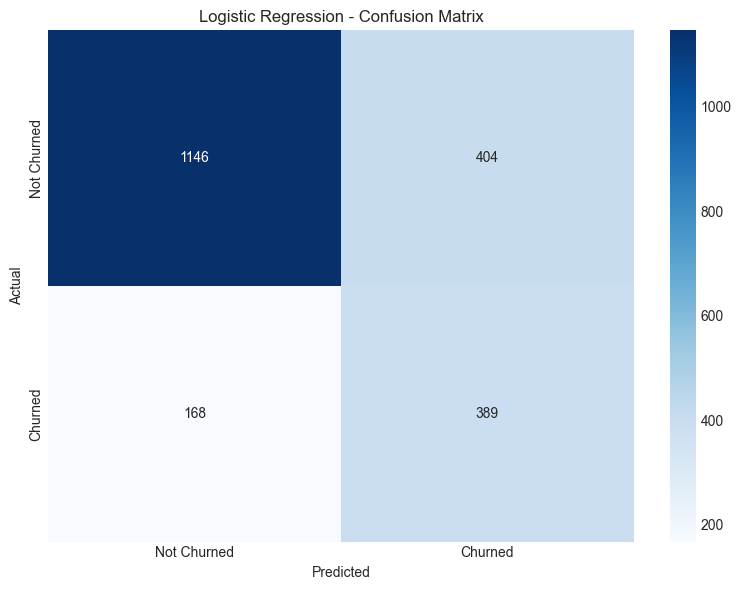

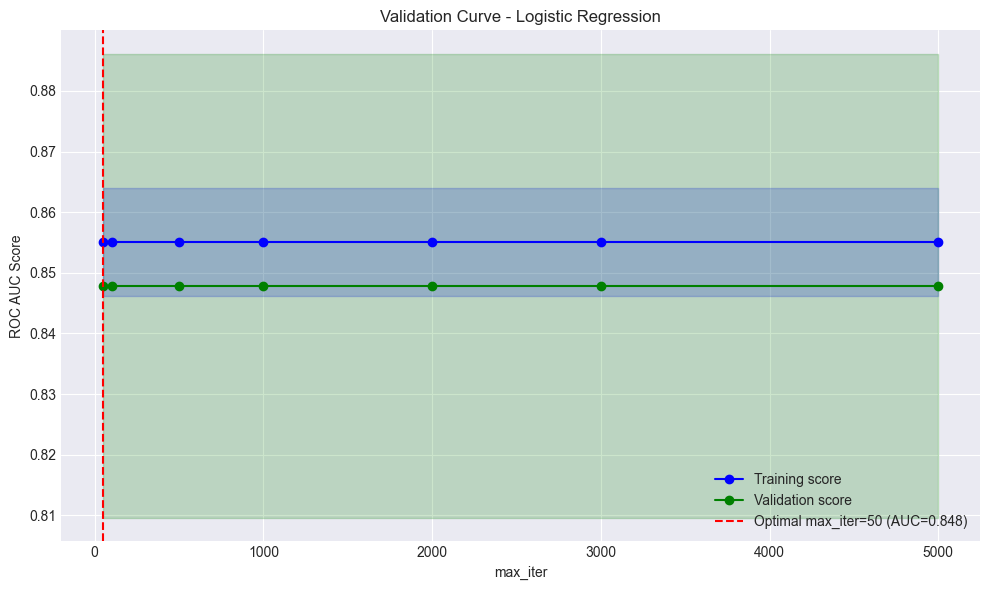

Optimal max_iter:    50
Best Validation AUC: 0.8478


In [ ]:
# Features & Target 
lrX = df.drop('churn', axis=1).select_dtypes(include=np.number)
lry = df['churn']

# Train-Test Split 
lrX_train, lrX_test, lry_train, lry_test = train_test_split(
    lrX, lry, test_size=0.3, random_state=42, stratify=lry
)

# Apply SMOTE 
smote = SMOTE(random_state=42)
lrX_resampled, lry_resampled = smote.fit_resample(lrX_train, lry_train)

# Train Model 
lr_model = LogisticRegression(max_iter=10000, solver='liblinear')
lr_model.fit(lrX_resampled, lry_resampled)

# Predictions 
lry_pred       = lr_model.predict(lrX_test)
lry_pred_proba = lr_model.predict_proba(lrX_test)[:, 1]

#  Metrics
print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(classification_report(lry_test, lry_pred, target_names=['Not Churned', 'Churned']))
print(f"Accuracy: {accuracy_score(lry_test, lry_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(lry_test, lry_pred_proba):.4f}")

# Confusion Matrix 
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(lry_test, lry_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

# Validation Curve
param_range = [50, 100, 500, 1000, 2000, 3000, 5000]

train_scores, val_scores = validation_curve(
    LogisticRegression(solver='liblinear'),
    lrX_resampled, lry_resampled,
    param_name="max_iter",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

best_idx  = np.argmax(val_mean)
best_iter = param_range[best_idx]
best_auc  = val_mean[best_idx]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_iter, color='red', linestyle='--',
           label=f'Optimal max_iter={best_iter} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - Logistic Regression')
ax.set_xlabel('max_iter')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal max_iter:    {best_iter}")
print(f"Best Validation AUC: {best_auc:.4f}")

# ------------------ RANDOM FOREST MODEL ------------------ #


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 Not Churned       0.82      0.89      0.86      1556
     Churned       0.60      0.45      0.52       551

    accuracy                           0.78      2107
   macro avg       0.71      0.67      0.69      2107
weighted avg       0.76      0.78      0.77      2107

Accuracy: 0.7779
ROC-AUC:  0.7923


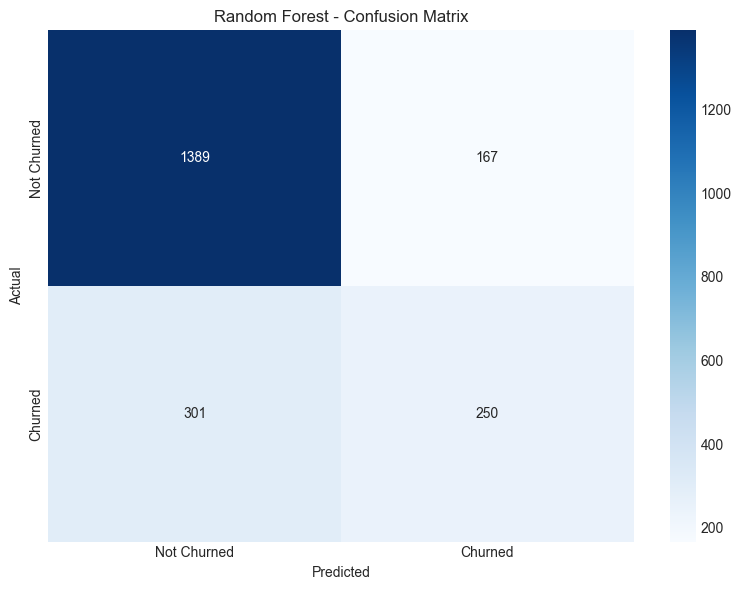

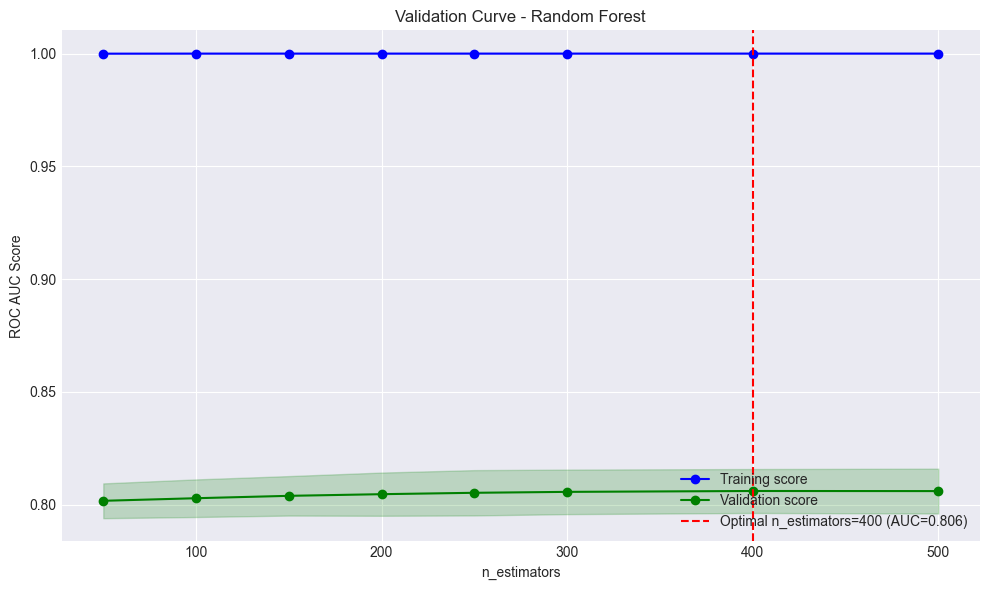

Optimal n_estimators: 400
Best Validation AUC:  0.8060


In [76]:
# Features & Target
rfX = df.drop('churn', axis=1).select_dtypes(include=np.number)
rfy = df['churn']

# Train-Test Split
rfX_train, rfX_test, rfy_train, rfy_test = train_test_split(
    rfX, rfy, test_size=0.3, random_state=42
)

# Train Model
forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
forest.fit(rfX_train, rfy_train)

# Predictions
rfy_pred       = forest.predict(rfX_test)
rfy_pred_proba = forest.predict_proba(rfX_test)[:, 1]

# Metrics
print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(classification_report(rfy_test, rfy_pred, target_names=['Not Churned', 'Churned']))
print(f"Accuracy: {accuracy_score(rfy_test, rfy_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(rfy_test, rfy_pred_proba):.4f}")

# Confusion Matrix
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(rfy_test, rfy_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

# Validation Curve
param_range = [50, 100, 150, 200, 250, 300, 400, 500]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(max_depth=None, random_state=42, n_jobs=-1),
    rfX_train, rfy_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

best_idx = np.argmax(val_mean)
best_n   = param_range[best_idx]
best_auc = val_mean[best_idx]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_n, color='red', linestyle='--',
           label=f'Optimal n_estimators={best_n} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - Random Forest')
ax.set_xlabel('n_estimators')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal n_estimators: {best_n}")
print(f"Best Validation AUC:  {best_auc:.4f}")

## CHECKING SVM ASSUMPTIONS.

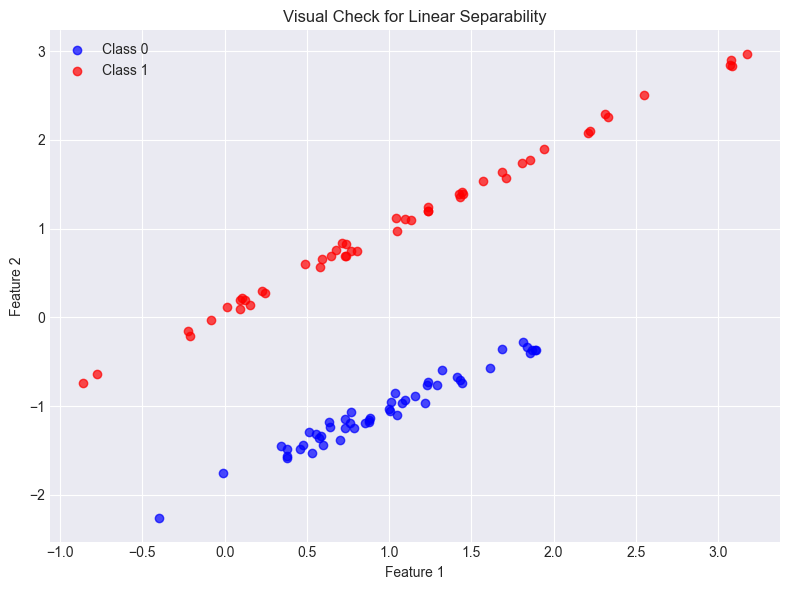

In [77]:
# Check for Linear Separability
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, random_state=42)

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='Class 0', alpha=0.7)
ax.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='Class 1', alpha=0.7)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Visual Check for Linear Separability')
ax.legend()
plt.tight_layout()
plt.show()

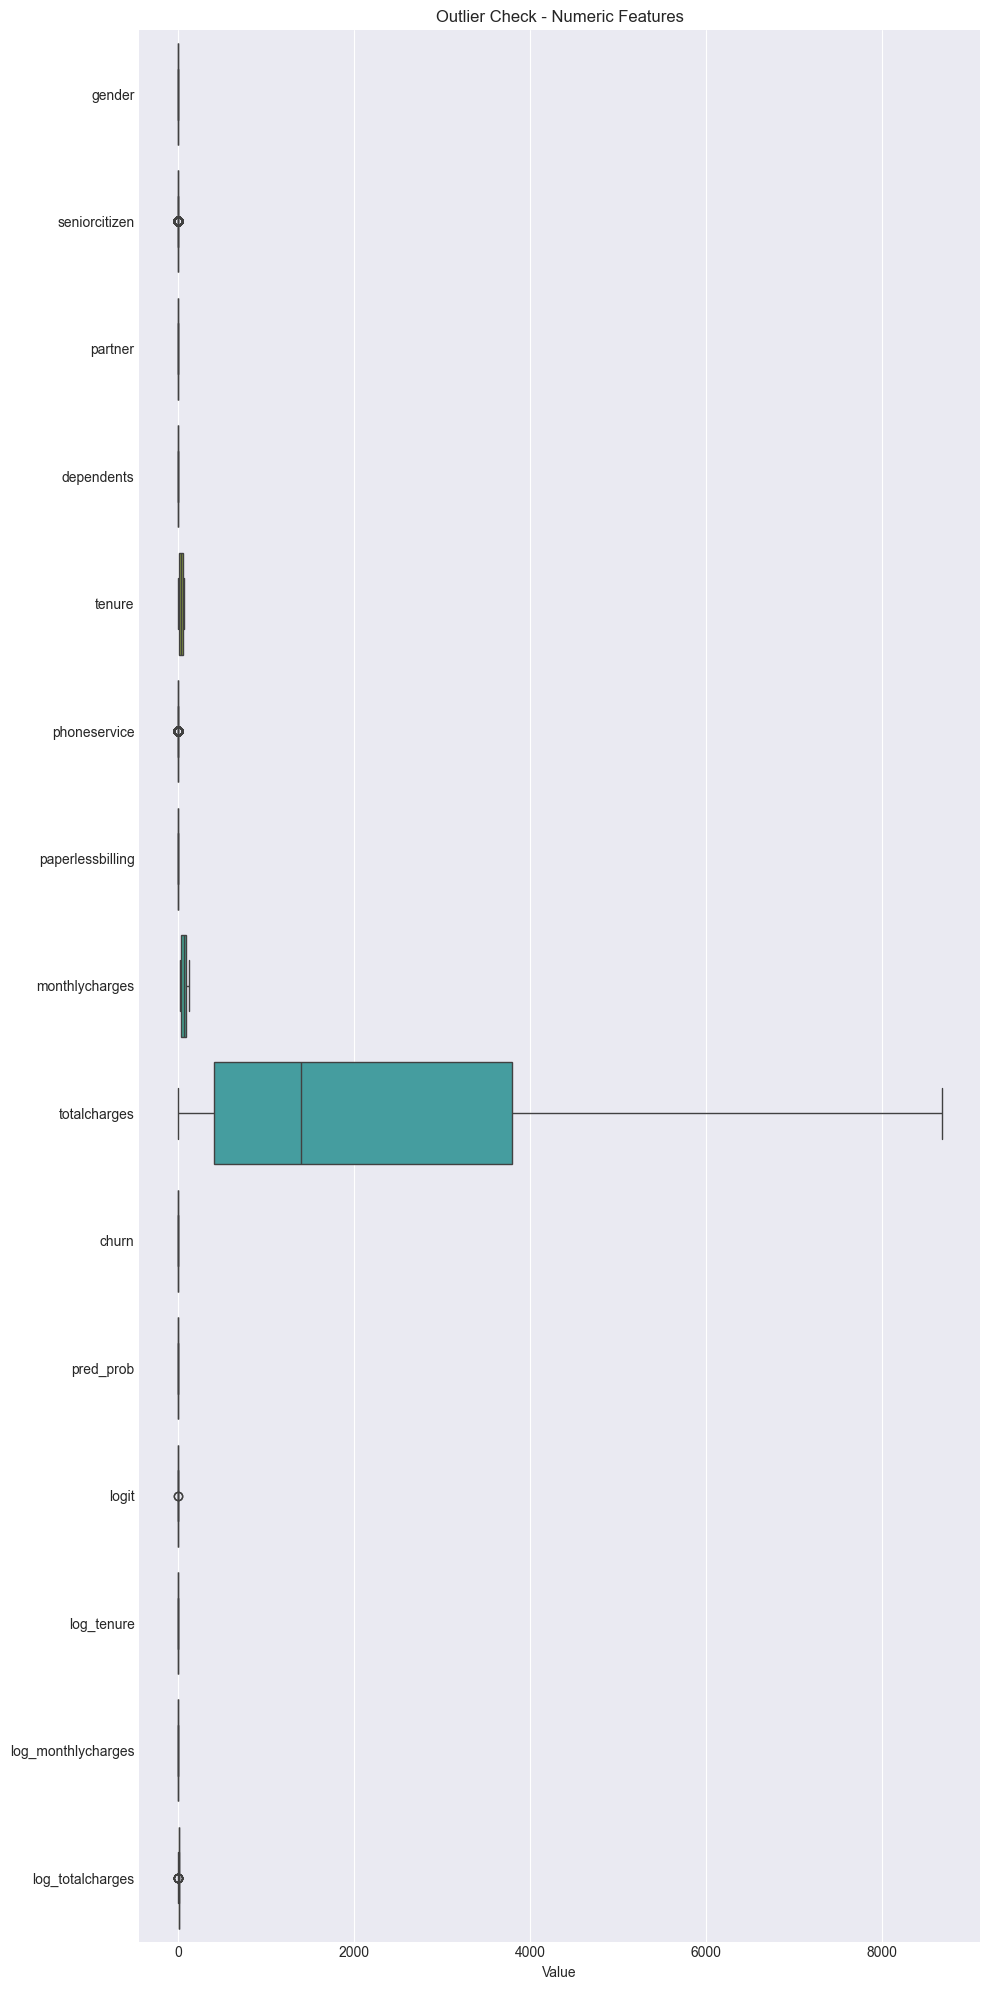

In [78]:

# Checking for outliers
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 20))

sns.boxplot(data=numeric_df, orient='h', ax=ax)

ax.set_title('Outlier Check - Numeric Features')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()


SVM RESULTS
              precision    recall  f1-score   support

 Not Churned       0.81      0.92      0.87      1556
     Churned       0.65      0.41      0.50       551

    accuracy                           0.79      2107
   macro avg       0.73      0.67      0.68      2107
weighted avg       0.77      0.79      0.77      2107

Accuracy: 0.7879
ROC-AUC:  0.7712


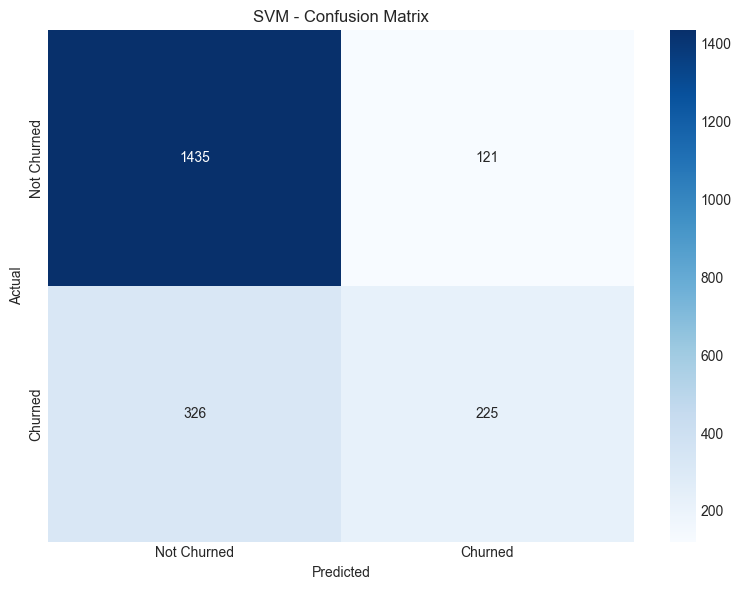

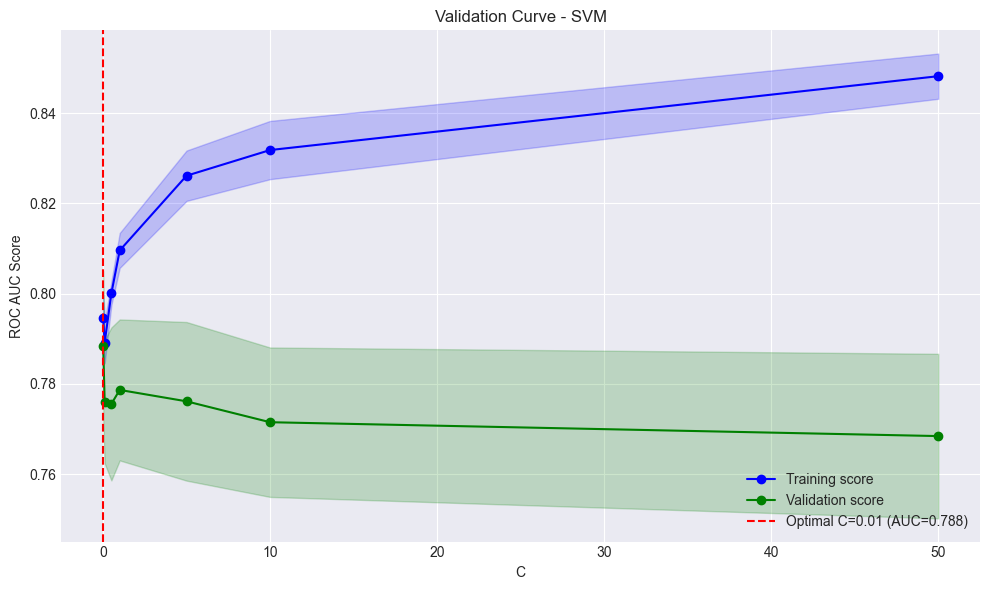

Optimal C:           0.01
Best Validation AUC: 0.7884


In [80]:
# Features & Target
svmX = df.drop('churn', axis=1).select_dtypes(include=np.number)
svmy = df['churn']

# Train-Test Split
svmX_train, svmX_test, svmy_train, svmy_test = train_test_split(
    svmX, svmy, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
svmX_train_scaled = scaler.fit_transform(svmX_train)
svmX_test_scaled  = scaler.transform(svmX_test)

# Train Model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True)
svm_model.fit(svmX_train_scaled, svmy_train)

# Predictions
svmy_pred       = svm_model.predict(svmX_test_scaled)
svmy_pred_proba = svm_model.predict_proba(svmX_test_scaled)[:, 1]

# Metrics
print("\n" + "="*60)
print("SVM RESULTS")
print("="*60)
print(classification_report(svmy_test, svmy_pred, target_names=['Not Churned', 'Churned']))
print(f"Accuracy: {accuracy_score(svmy_test, svmy_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(svmy_test, svmy_pred_proba):.4f}")

# Confusion Matrix
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(svmy_test, svmy_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('SVM - Confusion Matrix')
plt.tight_layout()
plt.show()

# Validation Curve
param_range = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

train_scores, val_scores = validation_curve(
    SVC(kernel="rbf", gamma="scale", probability=True),
    svmX_train_scaled, svmy_train,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

best_idx = np.argmax(val_mean)
best_c   = param_range[best_idx]
best_auc = val_mean[best_idx]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_c, color='red', linestyle='--',
           label=f'Optimal C={best_c} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - SVM')
ax.set_xlabel('C')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal C:           {best_c}")
print(f"Best Validation AUC: {best_auc:.4f}")

Before SMOTE: {0: 3614, 1: 1300}
After SMOTE: {0: 3614, 1: 3614}

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.89      0.71      0.79      1550
     Churned       0.49      0.77      0.59       557

    accuracy                           0.72      2107
   macro avg       0.69      0.74      0.69      2107
weighted avg       0.79      0.72      0.74      2107



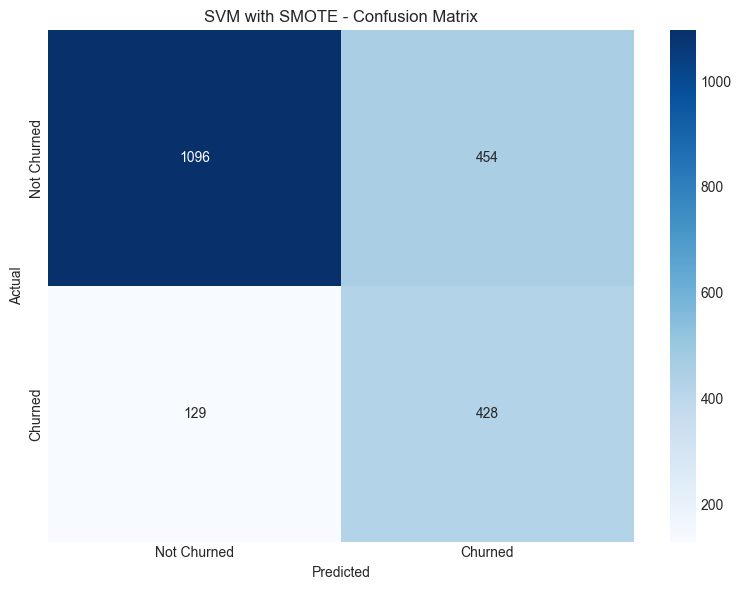

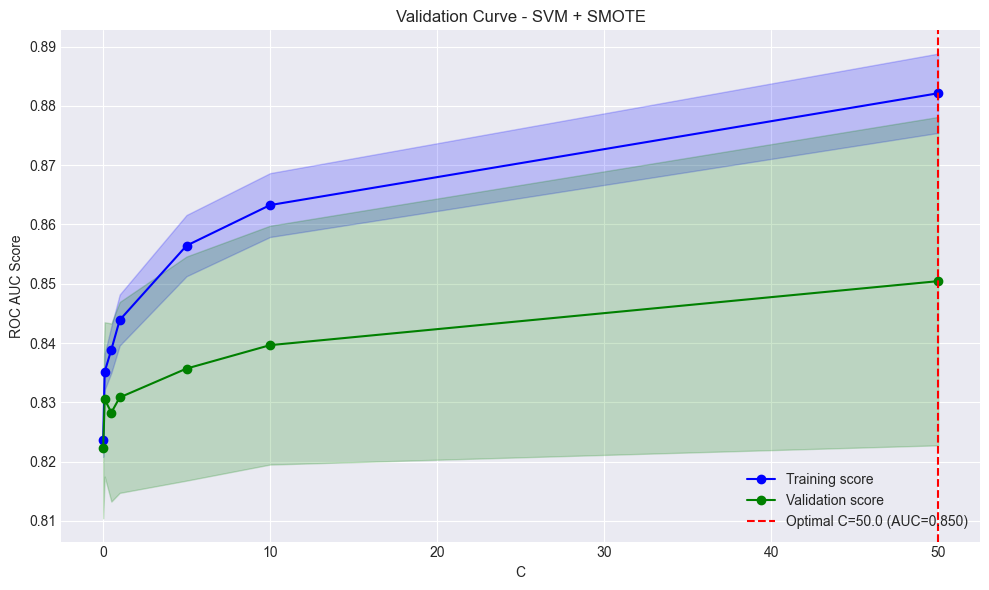

Optimal C: 50.0
Best Validation AUC: 0.8504


In [81]:


svmX = df.drop('churn', axis=1).select_dtypes(include=np.number)
svmy = df['churn']

# Train-test s
svmX_train, svmX_test, svmy_train, svmy_test = train_test_split(
    svmX, svmy, test_size=0.3, random_state=42, stratify=svmy
)

# Feature scaling
scaler = StandardScaler()
svmX_train_scaled = scaler.fit_transform(svmX_train)
svmX_test_scaled  = scaler.transform(svmX_test)

# SMOTE
smote = SMOTE(random_state=42)
svmX_train_resampled, svmy_train_resampled = smote.fit_resample(svmX_train_scaled, svmy_train)

print(f"Before SMOTE: {svmy_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(svmy_train_resampled).value_counts().to_dict()}")

# SVM model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_model.fit(svmX_train_resampled, svmy_train_resampled)

# Predict
svmy_pred = svm_model.predict(svmX_test_scaled)
svmy_pred_proba = svm_model.predict_proba(svmX_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(svmy_test, svmy_pred, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(svmy_test, svmy_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('SVM with SMOTE - Confusion Matrix')
plt.tight_layout()
plt.show()

# Validation Curve - SVM + SMOTE
from sklearn.model_selection import validation_curve

param_range = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

train_scores, val_scores = validation_curve(
    SVC(kernel="rbf", gamma="scale", probability=True),
    svmX_train_resampled, svmy_train_resampled,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Means and stds
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Best param
best_idx = np.argmax(val_mean)
best_c   = param_range[best_idx]
best_auc = val_mean[best_idx]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_c, color='red', linestyle='--',
           label=f'Optimal C={best_c} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - SVM + SMOTE')
ax.set_xlabel('C')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal C: {best_c}")
print(f"Best Validation AUC: {best_auc:.4f}")


Threshold 0.45: Precision=0.514, Recall=0.682, F1=0.586
Threshold 0.50: Precision=0.524, Recall=0.655, F1=0.583
Threshold 0.55: Precision=0.543, Recall=0.634, F1=0.585
Threshold 0.60: Precision=0.563, Recall=0.610, F1=0.586
Threshold 0.65: Precision=0.588, Recall=0.571, F1=0.579

Best threshold: 0.45

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.87      0.77      0.82      1550
     Churned       0.51      0.68      0.59       557

    accuracy                           0.75      2107
   macro avg       0.69      0.73      0.70      2107
weighted avg       0.78      0.75      0.76      2107



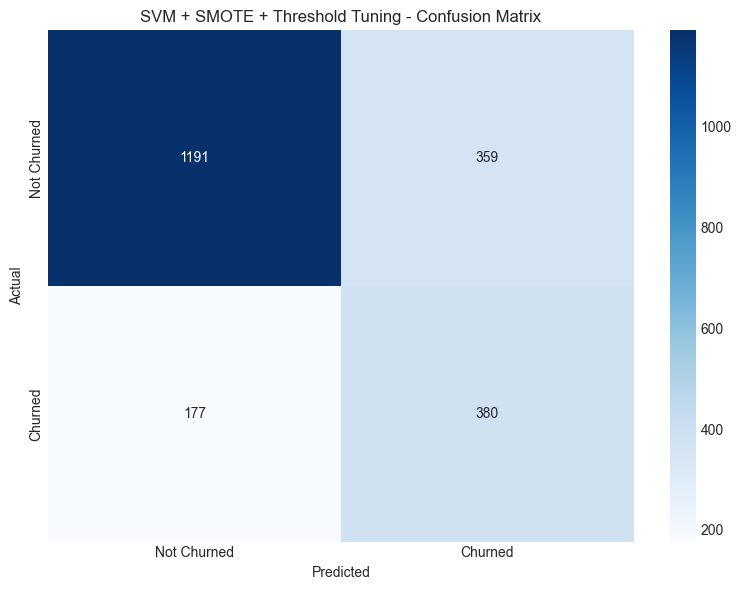

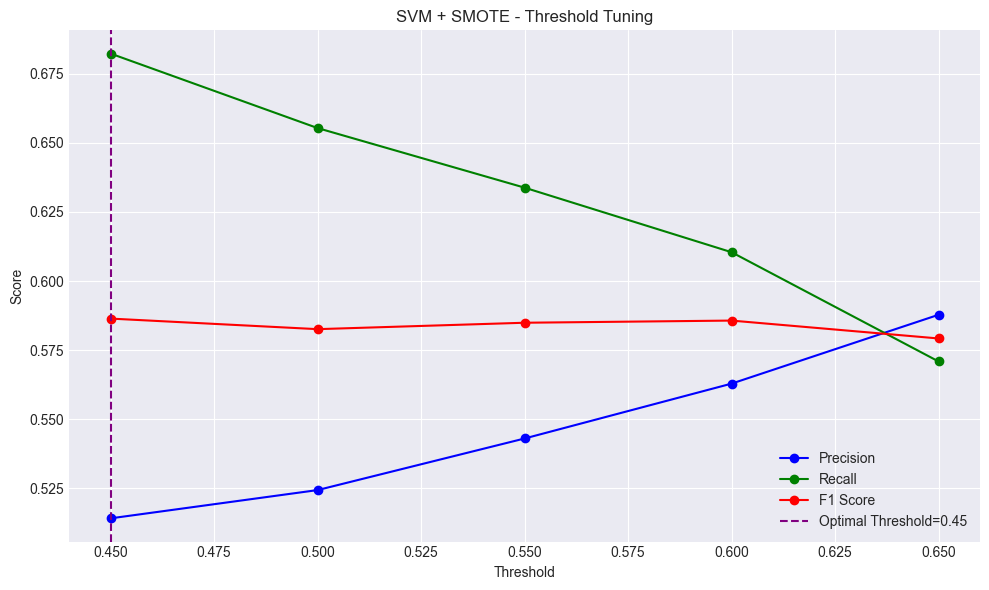

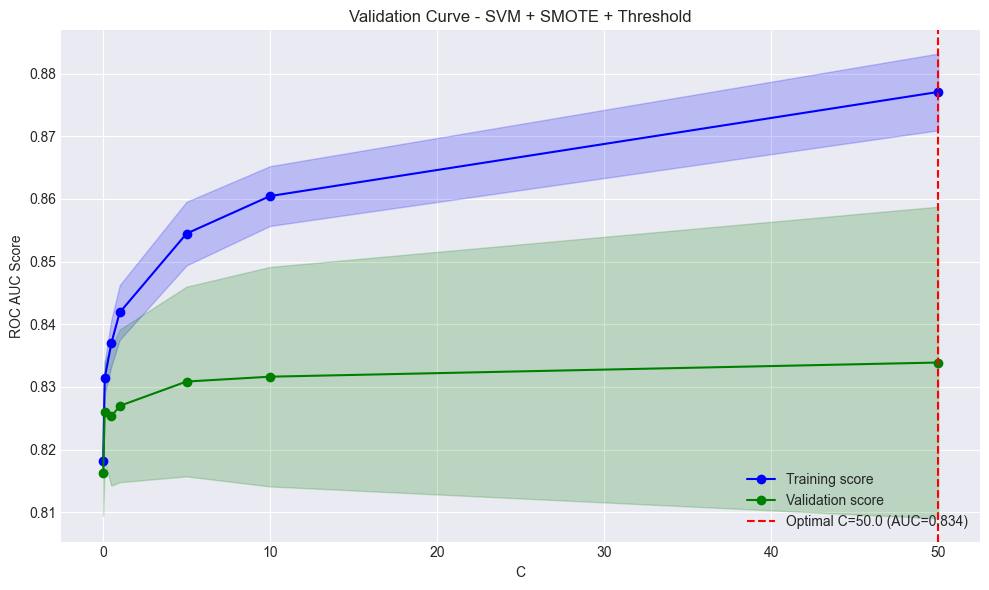

Optimal C: 50.0
Best Validation AUC: 0.8339

Default Threshold (0.5)  — Precision: 0.524, Recall: 0.655
Optimal Threshold (0.45) — Precision: 0.514, Recall: 0.682


In [189]:
# ------------------ SVM WITH SMOTE + THRESHOLD TUNING ------------------ #

svmX = df.drop('churn', axis=1).select_dtypes(include=np.number)
svmy = df['churn']

# Train-test split
svmX_train, svmX_test, svmy_train, svmy_test = train_test_split(
    svmX, svmy, test_size=0.3, random_state=42, stratify=svmy
)

# Scaling
scaler = StandardScaler()
svmX_train_scaled = scaler.fit_transform(svmX_train)
svmX_test_scaled  = scaler.transform(svmX_test)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.75, random_state=42)
svmX_train_resampled, svmy_train_resampled = smote.fit_resample(
    svmX_train_scaled, svmy_train
)

# Train SVM model
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)
svm_model.fit(svmX_train_resampled, svmy_train_resampled)

# Predict probabilities
svmy_pred_proba = svm_model.predict_proba(svmX_test_scaled)[:, 1]

# Threshold tuning
thresholds = [0.45, 0.50, 0.55, 0.60, 0.65]
results = []

for threshold in thresholds:
    y_pred_thresh = (svmy_pred_proba >= threshold).astype(int)
    prec = precision_score(svmy_test, y_pred_thresh)
    rec  = recall_score(svmy_test, y_pred_thresh)
    f1   = f1_score(svmy_test, y_pred_thresh)
    results.append({'Threshold': threshold, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"Threshold {threshold:.2f}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

results_df = pd.DataFrame(results)

# Optimal threshold
best_idx          = results_df['F1'].idxmax()
optimal_threshold = results_df.loc[best_idx, 'Threshold']
print(f"\nBest threshold: {optimal_threshold}")

# Final prediction using optimal threshold
svmy_pred_optimal = (svmy_pred_proba >= optimal_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(svmy_test, svmy_pred_optimal, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(svmy_test, svmy_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('SVM + SMOTE + Threshold Tuning - Confusion Matrix')
plt.tight_layout()
plt.show()

# Threshold tuning plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results_df['Threshold'], results_df['Precision'], 'b-o', label='Precision')
ax.plot(results_df['Threshold'], results_df['Recall'],    'g-o', label='Recall')
ax.plot(results_df['Threshold'], results_df['F1'],        'r-o', label='F1 Score')

ax.axvline(x=optimal_threshold, color='purple', linestyle='--',
           label=f'Optimal Threshold={optimal_threshold}')

ax.set_title('SVM + SMOTE - Threshold Tuning')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Validation Curve - SVM + SMOTE + Threshold
from sklearn.model_selection import validation_curve

param_range = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]

train_scores, val_scores = validation_curve(
    SVC(kernel="rbf", gamma="scale", probability=True),
    svmX_train_resampled, svmy_train_resampled,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Means and stds
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Best param
best_idx = np.argmax(val_mean)
best_c   = param_range[best_idx]
best_auc = val_mean[best_idx]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_c, color='red', linestyle='--',
           label=f'Optimal C={best_c} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - SVM + SMOTE + Threshold')
ax.set_xlabel('C')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal C: {best_c}")
print(f"Best Validation AUC: {best_auc:.4f}")

# Default threshold comparison
default_pred      = (svmy_pred_proba >= 0.5).astype(int)
default_precision = precision_score(svmy_test, default_pred)
default_recall    = recall_score(svmy_test, default_pred)

print(f"\nDefault Threshold (0.5)  — Precision: {default_precision:.3f}, Recall: {default_recall:.3f}")
print(f"Optimal Threshold ({optimal_threshold}) — Precision: {precision_score(svmy_test, svmy_pred_optimal):.3f}, Recall: {recall_score(svmy_test, svmy_pred_optimal):.3f}")

# ------------------ XGBOOST IMPLEMENTATION ------------------ #

[0]	train-logloss:0.66510	test-logloss:0.66579
[10]	train-logloss:0.54465	test-logloss:0.54855
[20]	train-logloss:0.51415	test-logloss:0.52058
[30]	train-logloss:0.50175	test-logloss:0.51297
[40]	train-logloss:0.49410	test-logloss:0.50880
[49]	train-logloss:0.48941	test-logloss:0.50655

XGBOOST RESULTS
Accuracy:  0.7337
Precision: 0.4977
Recall:    0.7828
F1-Score:  0.6085
ROC-AUC:   0.8291

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.90      0.72      0.80      1550
     Churned       0.50      0.78      0.61       557

    accuracy                           0.73      2107
   macro avg       0.70      0.75      0.70      2107
weighted avg       0.79      0.73      0.75      2107



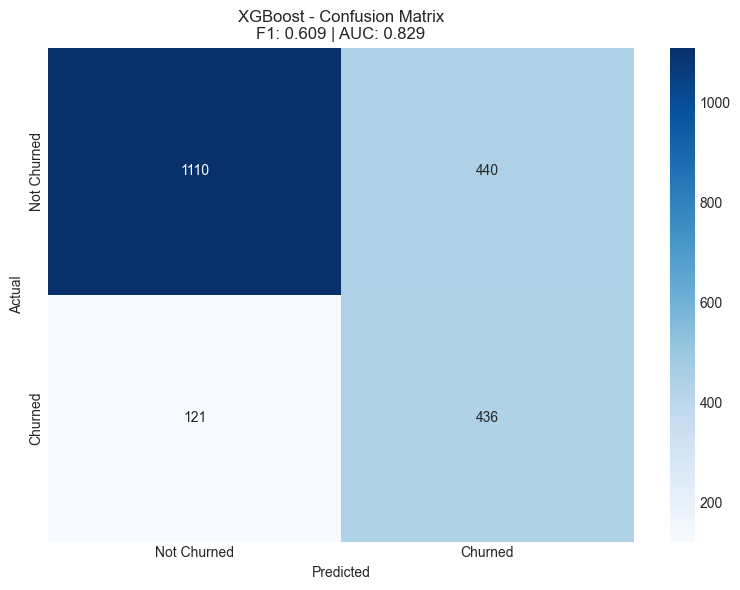

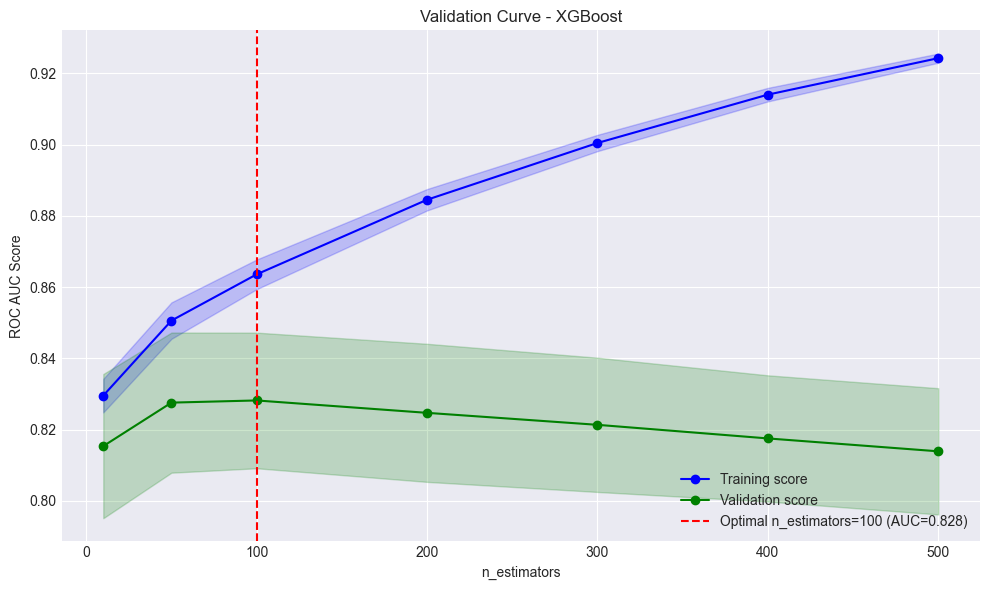

Optimal n_estimators: 100
Best Validation AUC:  0.8282


In [83]:
# Features and target
xgbX = df.drop('churn', axis=1).select_dtypes(include=np.number)
xgby = df['churn']

# Train-test split (stratified)
xgbX_train, xgbX_test, xgby_train, xgby_test = train_test_split(
    xgbX, xgby,
    test_size=0.3,
    random_state=42,
    stratify=xgby
)

# Convert to DMatrix
xgb_train = xgb.DMatrix(xgbX_train, label=xgby_train)
xgb_test  = xgb.DMatrix(xgbX_test,  label=xgby_test)

# Class imbalance handling
scale_pos = len(xgby_train[xgby_train == 0]) / len(xgby_train[xgby_train == 1])

params = {
    'objective':        'binary:logistic',
    'max_depth':        3,
    'learning_rate':    0.1,
    'eval_metric':      'logloss',
    'scale_pos_weight': scale_pos
}

# Train model with early stopping
evals = [(xgb_train, "train"), (xgb_test, "test")]

model = xgb.train(
    params=params,
    dtrain=xgb_train,
    num_boost_round=50,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=10
)

# Predictions
xgby_pred_proba = model.predict(xgb_test)
xgby_pred       = (xgby_pred_proba > 0.5).astype(int)

# Performance metrics
accuracy  = accuracy_score(xgby_test, xgby_pred)
precision = precision_score(xgby_test, xgby_pred)
recall    = recall_score(xgby_test, xgby_pred)
f1        = f1_score(xgby_test, xgby_pred)
roc_auc   = roc_auc_score(xgby_test, xgby_pred_proba)

print("\n" + "="*60)
print("XGBOOST RESULTS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(xgby_test, xgby_pred, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(xgby_test, xgby_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=ax)

ax.set_title(f'XGBoost - Confusion Matrix\nF1: {f1:.3f} | AUC: {roc_auc:.3f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Validation Curve - XGBoost
from sklearn.model_selection import validation_curve
from xgboost import XGBClassifier

param_range = [10, 50, 100, 200, 300, 400, 500]

train_scores, val_scores = validation_curve(
    XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    xgbX_train, xgby_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Means and stds
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Best param
best_idx         = np.argmax(val_mean)
best_n_estimators = param_range[best_idx]
best_auc         = val_mean[best_idx]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(param_range, train_mean, 'b-o', label='Training score')
ax.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, alpha=0.2, color='blue')

ax.plot(param_range, val_mean, 'g-o', label='Validation score')
ax.fill_between(param_range, val_mean - val_std,
                val_mean + val_std, alpha=0.2, color='green')

ax.axvline(x=best_n_estimators, color='red', linestyle='--',
           label=f'Optimal n_estimators={best_n_estimators} (AUC={best_auc:.3f})')

ax.set_title('Validation Curve - XGBoost')
ax.set_xlabel('n_estimators')
ax.set_ylabel('ROC AUC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Optimal n_estimators: {best_n_estimators}")
print(f"Best Validation AUC:  {best_auc:.4f}")

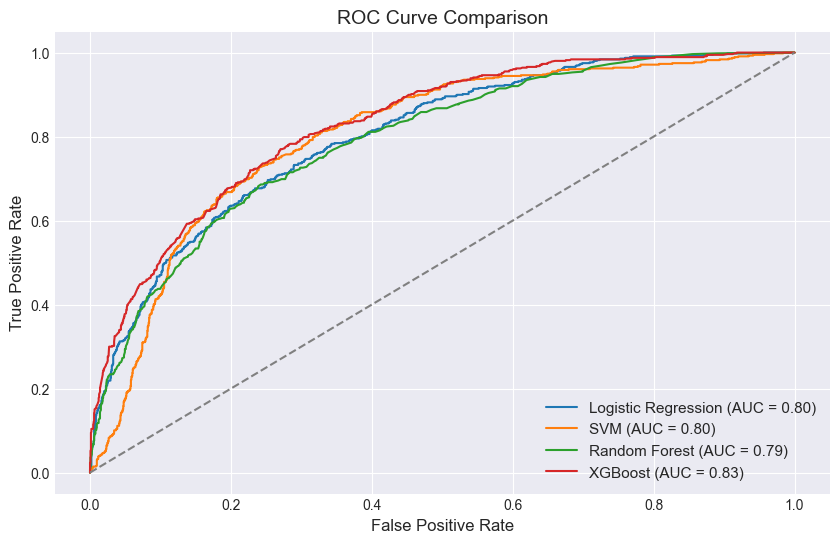

In [84]:

# ------------------ COMPUTE ROC VALUES ------------------ #
# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(lry_test, lry_pred_proba)

# # SVM
fpr_svm, tpr_svm, _ = roc_curve(svmy_test, svmy_pred_proba)

# # Random Forest
fpr_rf, tpr_rf, _ = roc_curve(rfy_test, rfy_pred_proba)

# # XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(xgby_test, xgby_pred_proba)

# # ------------------ PLOT ROC CURVE ------------------ #
plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(lry_test, lry_pred_proba):.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_score(svmy_test, svmy_pred_proba):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(rfy_test, rfy_pred_proba):.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(xgby_test, xgby_pred_proba):.2f})")

# # Baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True)
plt.show()


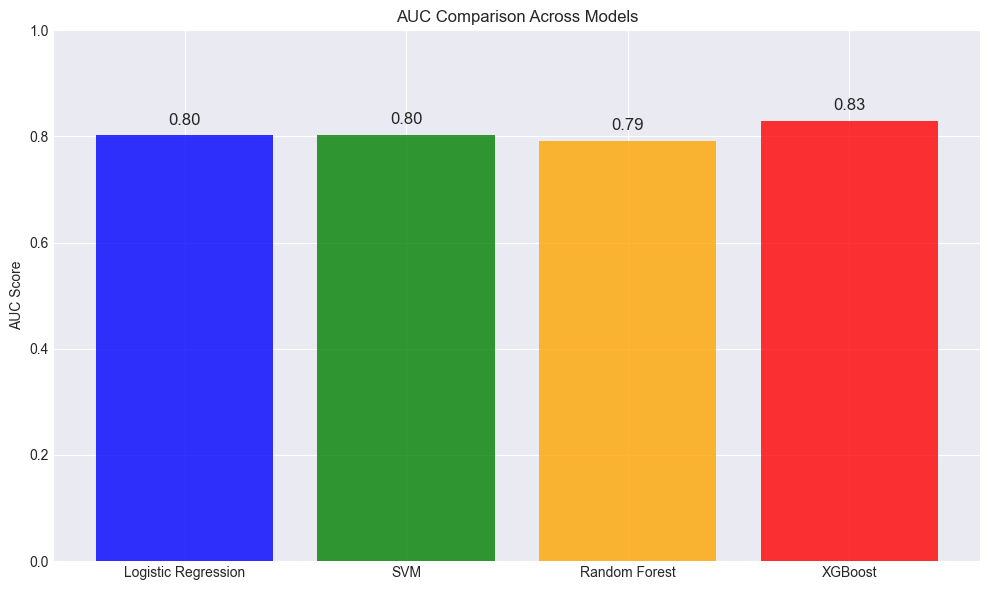

In [85]:

# ------------------ COMPUTE AUC VALUES ------------------ #
auc_lr  = roc_auc_score(lry_test,  lry_pred_proba)
auc_svm = roc_auc_score(svmy_test, svmy_pred_proba)
auc_rf  = roc_auc_score(rfy_test,  rfy_pred_proba)
auc_xgb = roc_auc_score(xgby_test, xgby_pred_proba)

model_names = ["Logistic Regression", "SVM", "Random Forest", "XGBoost"]
auc_scores  = [auc_lr, auc_svm, auc_rf, auc_xgb]

# ------------------ PLOT BAR CHART ------------------ #
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(model_names, auc_scores, color=['blue', 'green', 'orange', 'red'], alpha=0.8)

ax.set_ylabel('AUC Score')
ax.set_title('AUC Comparison Across Models')
ax.set_ylim(0, 1)

# Label each bar
for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            score + 0.02,
            f"{score:.2f}",
            ha='center',
            fontsize=12)

plt.tight_layout()
plt.show()

In [86]:
cv_results = xgb.cv(
    params=params,
    dtrain=xgb.DMatrix(xgbX, label=xgby),
    num_boost_round=200,
    nfold=5,
    stratified=True,
    metrics="auc",
    early_stopping_rounds=10,
    seed=42
)
print(cv_results)
cv_results.tail()

    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0         0.809736       0.002444       0.800214      0.011063
1         0.816388       0.003751       0.806586      0.010561
2         0.820748       0.002740       0.811171      0.011439
3         0.822019       0.002656       0.813060      0.010784
4         0.823876       0.002363       0.814505      0.010095
..             ...            ...            ...           ...
75        0.849590       0.001698       0.829038      0.007093
76        0.849815       0.001699       0.829110      0.007056
77        0.850035       0.001840       0.829139      0.007086
78        0.850246       0.001683       0.829123      0.007099
79        0.850472       0.001688       0.829208      0.007173

[80 rows x 4 columns]


,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
75,0.849590,0.001698,0.829038,0.007093
76,0.849815,0.001699,0.829110,0.007056
77,0.850035,0.001840,0.829139,0.007086
78,0.850246,0.001683,0.829123,0.007099
79,0.850472,0.001688,0.829208,0.007173


In [87]:
best_auc = cv_results["test-auc-mean"].max()

print(f"best_auc: {best_auc}")

best_auc: 0.8292078426648507


In [88]:
best_round = cv_results["test-auc-mean"].idxmax()
print(f"best_round: {best_round}")


best_round: 79


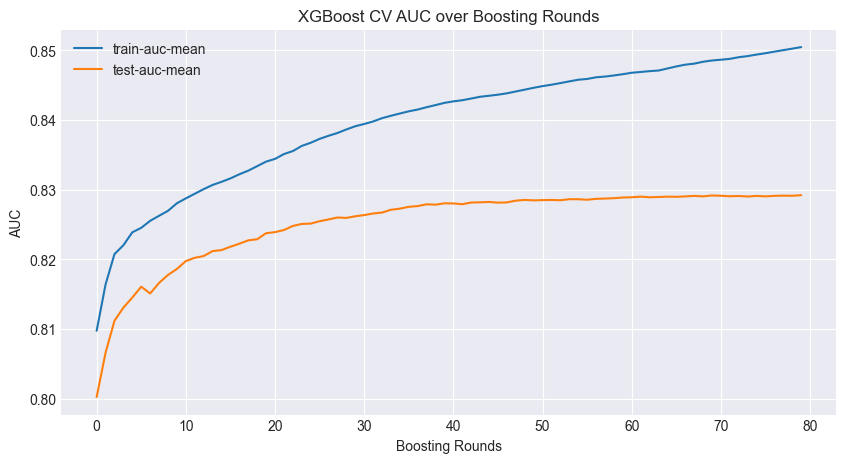

In [89]:
cv_results[["train-auc-mean", "test-auc-mean"]].plot(figsize=(10,5))
plt.title("XGBoost CV AUC over Boosting Rounds")
plt.xlabel("Boosting Rounds")
plt.ylabel("AUC")
plt.grid(True)
plt.show()



In [90]:

## now that we have trained the model, we can look at the features that are important.
importance = model.get_score()
importance = model.get_score(importance_type='gain')
pd.DataFrame({
    "feature": importance.keys(),
    "importance": importance.values()
}).sort_values("importance", ascending=False)


,feature,importance
9,pred_prob,136.534988
6,paperlessbilling,34.073746
1,seniorcitizen,19.608627
3,dependents,16.830149
5,phoneservice,15.569779
7,monthlycharges,14.649055
4,tenure,13.860016
8,totalcharges,11.184643
2,partner,4.677481
0,gender,3.347232


<Figure size 1000x800 with 0 Axes>

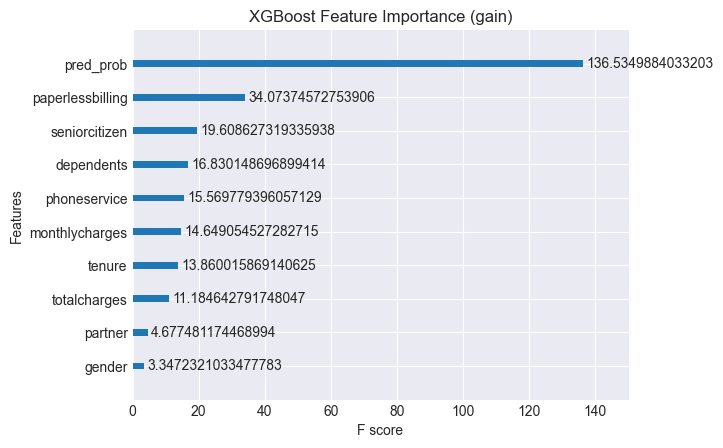

In [91]:
plt.figure(figsize=(10, 8))
plot_importance(model, importance_type='gain') 
plt.title("XGBoost Feature Importance (gain)")
plt.show()

In [92]:
## saving the best model
model.save_model("data/models/best_xgb_model.json")
